# Statistical Analysis of Targeted Infusion

This notebook implements four statistical tests to validate that infusion creates **targeted** changes to the target class probability:

1. **Increase in Target-Class Probability**: Test if infusion systematically increases target class probability
2. **One-vs-Rest Contrast**: Test if target class increases MORE than non-target classes
3. **Log-Odds Version**: Test target vs. rest using log-odds (entropy-robust)
4. **Permutation Test**: Entropy-agnostic test that chosen targets are special
5. **Targeted Success Rate**: Test improvement in classification accuracy for target class

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from glob import glob
from scipy import stats
from tqdm import tqdm

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Configuration

In [ ]:
RESULTS_DIR = './results/random_test_infusion/'
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
K = 10  # Number of classes

print(f"Analyzing results from: {RESULTS_DIR}")

Analyzing results from: ./results/random_test_infusion/


## Load Data

Load all experimental results and extract probability distributions before and after infusion.

In [3]:
def softmax(logits):
    """Compute softmax probabilities from logits"""
    exp_logits = np.exp(logits - np.max(logits, axis=-1, keepdims=True))
    return exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)

def load_experiment_result(exp_dir):
    """Load a single experiment result"""
    result_path = os.path.join(exp_dir, 'results.npz')
    if os.path.exists(result_path):
        return np.load(result_path, allow_pickle=True)
    return None

# Find all experiment directories
exp_dirs = sorted(glob(os.path.join(RESULTS_DIR, 'sample_*')))
print(f"Found {len(exp_dirs)} experiment directories")

# Load all data
data = []

print("Loading experimental results...")
for exp_dir in tqdm(exp_dirs):
    result = load_experiment_result(exp_dir)
    if result is None:
        continue
    
    # Extract data
    logits_pre = result['logits_epoch10'][0]  # Shape: (10,)
    logits_post = result['logits_infused'][0]  # Shape: (10,)
    
    # Convert to probabilities
    p_pre = softmax(logits_pre)
    p_post = softmax(logits_post)
    
    # Get metadata
    target_class = int(result['target_class'])
    true_label = int(result['true_label'])
    sample_idx = int(result['sample_idx'])
    test_image_idx = int(result['test_image_idx'])
    
    data.append({
        'sample_idx': sample_idx,
        'test_image_idx': test_image_idx,
        'true_label': true_label,
        'target_class': target_class,
        'p_pre': p_pre,
        'p_post': p_post,
    })

df = pd.DataFrame(data)

# LIMIT TO FIRST 2000 EXAMPLES
df = df.iloc[:2000]
N = len(df)

print(f"\nLoaded {N} experimental results (limited to first 2000)")
print(f"Unique test images: {df['test_image_idx'].nunique()}")
print(f"Target class distribution:")
print(df['target_class'].value_counts().sort_index())

Found 2404 experiment directories
Loading experimental results...


100%|██████████| 2404/2404 [00:07<00:00, 327.19it/s]


Loaded 2000 experimental results (limited to first 2000)
Unique test images: 200
Target class distribution:
target_class
0    200
1    200
2    200
3    200
4    200
5    200
6    200
7    200
8    200
9    200
Name: count, dtype: int64


## Test 1: Increase in Target-Class Probability

**Hypothesis:**
- $H_0$: $\mathbb{E}[\Delta_i] = 0$ (no systematic change in target probability)
- $H_1$: $\mathbb{E}[\Delta_i] > 0$ (infusion increases target probability)

where $\Delta_i = p^{\text{post}}_{i,t_i} - p^{\text{pre}}_{i,t_i}$

TEST 1: INCREASE IN TARGET-CLASS PROBABILITY

Summary Statistics:
  Sample size (N): 2000
  Mean Δ: 0.232195
  Std Δ: 0.275503
  Median Δ: 0.091646
  Min Δ: 0.000001
  Max Δ: 0.964307

Direction of change:
  Increased: 2000 (100.0%)
  Decreased: 0 (0.0%)
  Unchanged: 0 (0.0%)

Paired t-test:
  t-statistic: 37.6819
  p-value: 1.515135e-235
  Cohen's d: 0.8428

Wilcoxon signed-rank test:
  Statistic: 2001000.0000
  p-value: 0.000000e+00

Sign test:
  # Positive: 2000/2000
  p-value: 0.000000e+00


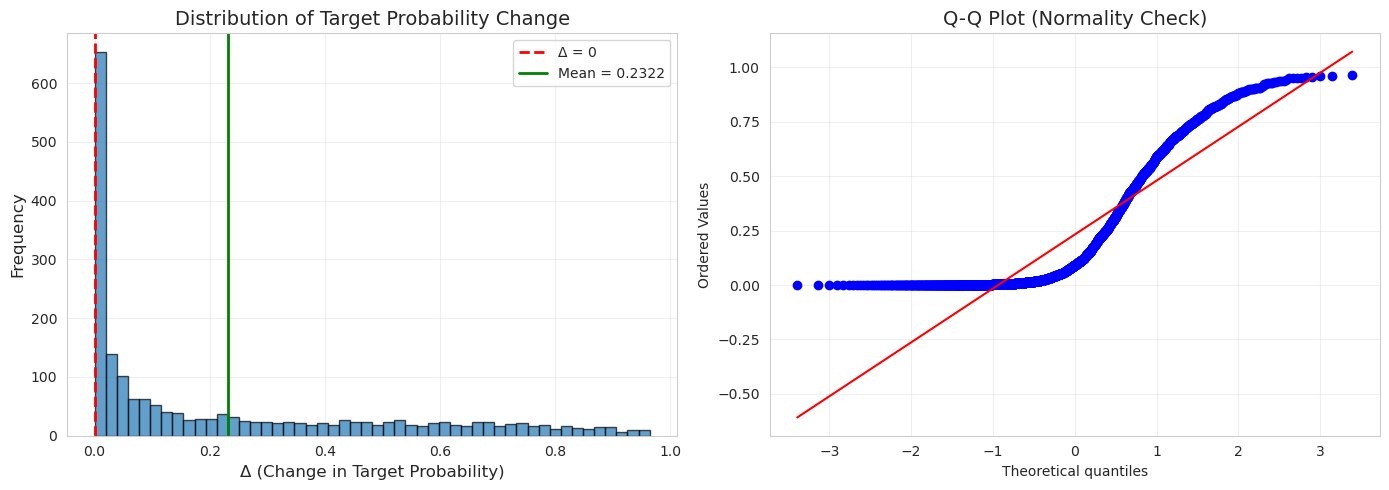


CONCLUSION: The target class probability SIGNIFICANTLY INCREASES


In [4]:
# Compute Δ_i for each probe
delta_target = np.array([
    row['p_post'][row['target_class']] - row['p_pre'][row['target_class']]
    for _, row in df.iterrows()
])

print("="*80)
print("TEST 1: INCREASE IN TARGET-CLASS PROBABILITY")
print("="*80)

# Summary statistics
print(f"\nSummary Statistics:")
print(f"  Sample size (N): {N}")
print(f"  Mean Δ: {delta_target.mean():.6f}")
print(f"  Std Δ: {delta_target.std():.6f}")
print(f"  Median Δ: {np.median(delta_target):.6f}")
print(f"  Min Δ: {delta_target.min():.6f}")
print(f"  Max Δ: {delta_target.max():.6f}")

# Count how many increased
n_positive = (delta_target > 0).sum()
n_negative = (delta_target < 0).sum()
n_zero = (delta_target == 0).sum()

print(f"\nDirection of change:")
print(f"  Increased: {n_positive} ({n_positive/N*100:.1f}%)")
print(f"  Decreased: {n_negative} ({n_negative/N*100:.1f}%)")
print(f"  Unchanged: {n_zero} ({n_zero/N*100:.1f}%)")

# Paired t-test (one-sided)
t_stat, p_value_t = stats.ttest_1samp(delta_target, 0, alternative='greater')
print(f"\nPaired t-test:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value_t:.6e}")

# Cohen's d (effect size)
cohens_d = delta_target.mean() / delta_target.std()
print(f"  Cohen's d: {cohens_d:.4f}")

# Wilcoxon signed-rank test (non-parametric)
wilcoxon_stat, p_value_wilcoxon = stats.wilcoxon(delta_target, alternative='greater')
print(f"\nWilcoxon signed-rank test:")
print(f"  Statistic: {wilcoxon_stat:.4f}")
print(f"  p-value: {p_value_wilcoxon:.6e}")

# Sign test using binomtest (the new SciPy API)
from scipy.stats import binomtest

binomtest_res = binomtest(n_positive, n=N, p=0.5, alternative='greater')
p_value_sign = binomtest_res.pvalue

print(f"\nSign test:")
print(f"  # Positive: {n_positive}/{N}")
print(f"  p-value: {p_value_sign:.6e}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(delta_target, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Δ = 0')
axes[0].axvline(delta_target.mean(), color='green', linestyle='-', linewidth=2, label=f'Mean = {delta_target.mean():.4f}')
axes[0].set_xlabel('Δ (Change in Target Probability)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Target Probability Change', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q plot (check normality)
stats.probplot(delta_target, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'test1_target_probability_increase.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*80}")
print(f"CONCLUSION: The target class probability {'SIGNIFICANTLY INCREASES' if p_value_t < 0.001 else 'does not significantly increase'}")
print(f"{'='*80}")

## Test 2: One-vs-Rest Contrast

Test if the target class increases **more than** the average of non-target classes.

**Hypothesis:**
- $H_0$: $\mathbb{E}[C_i] = 0$ (target increases same as non-targets)
- $H_1$: $\mathbb{E}[C_i] > 0$ (target increases more than non-targets)

where $C_i = (p^{\text{post}}_{i,t_i} - p^{\text{pre}}_{i,t_i}) - (\bar{p}^{\text{post}}_{i,\neg t} - \bar{p}^{\text{pre}}_{i,\neg t})$

TEST 2: ONE-VS-REST CONTRAST

Summary Statistics:
  Sample size (N): 2000
  Mean C: 0.257994
  Std C: 0.306114
  Median C: 0.101829

Paired t-test:
  t-statistic: 37.6819
  p-value: 1.515252e-235
  Cohen's d: 0.8428

Wilcoxon signed-rank test:
  Statistic: 2001000.0000
  p-value: 0.000000e+00


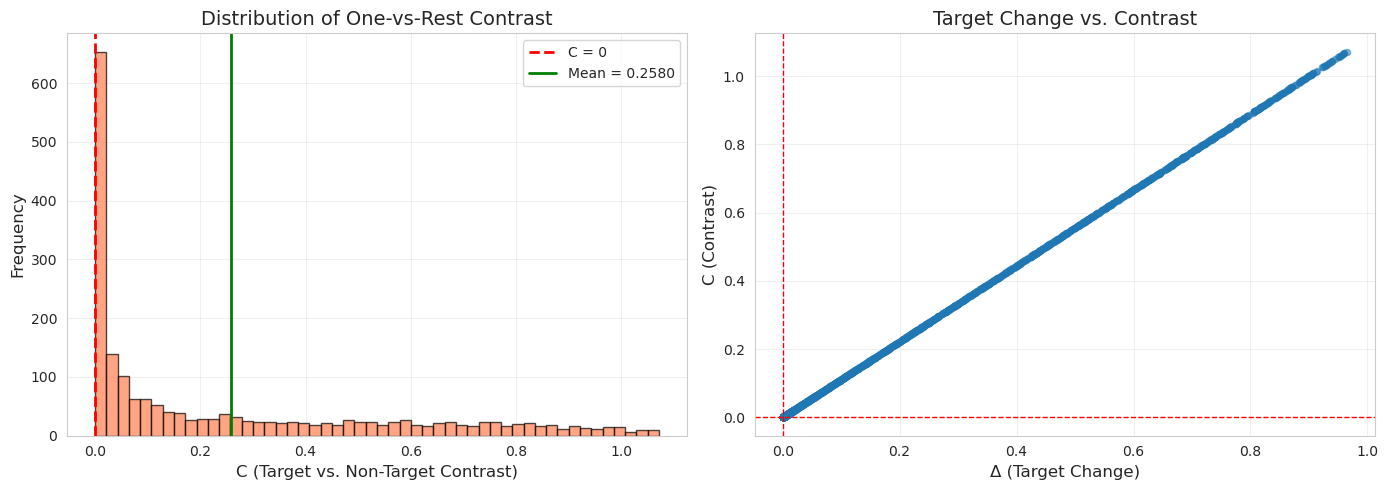


CONCLUSION: Target class SIGNIFICANTLY INCREASES MORE than non-target classes


In [5]:
# Compute contrast C_i for each probe
contrast = []

for _, row in df.iterrows():
    p_pre = row['p_pre']
    p_post = row['p_post']
    t_i = row['target_class']
    
    # Change in target class
    delta_target_i = p_post[t_i] - p_pre[t_i]
    
    # Average probability of non-target classes
    non_target_mask = np.ones(K, dtype=bool)
    non_target_mask[t_i] = False
    
    p_bar_pre = p_pre[non_target_mask].mean()
    p_bar_post = p_post[non_target_mask].mean()
    
    # Change in average non-target probability
    delta_non_target_i = p_bar_post - p_bar_pre
    
    # Contrast
    C_i = delta_target_i - delta_non_target_i
    contrast.append(C_i)

contrast = np.array(contrast)

print("="*80)
print("TEST 2: ONE-VS-REST CONTRAST")
print("="*80)

# Summary statistics
print(f"\nSummary Statistics:")
print(f"  Sample size (N): {N}")
print(f"  Mean C: {contrast.mean():.6f}")
print(f"  Std C: {contrast.std():.6f}")
print(f"  Median C: {np.median(contrast):.6f}")

# Paired t-test
t_stat, p_value = stats.ttest_1samp(contrast, 0, alternative='greater')
print(f"\nPaired t-test:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.6e}")

# Cohen's d
cohens_d = contrast.mean() / contrast.std()
print(f"  Cohen's d: {cohens_d:.4f}")

# Wilcoxon signed-rank test
wilcoxon_stat, p_value_wilcoxon = stats.wilcoxon(contrast, alternative='greater')
print(f"\nWilcoxon signed-rank test:")
print(f"  Statistic: {wilcoxon_stat:.4f}")
print(f"  p-value: {p_value_wilcoxon:.6e}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(contrast, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='C = 0')
axes[0].axvline(contrast.mean(), color='green', linestyle='-', linewidth=2, label=f'Mean = {contrast.mean():.4f}')
axes[0].set_xlabel('C (Target vs. Non-Target Contrast)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of One-vs-Rest Contrast', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scatter: delta_target vs contrast
axes[1].scatter(delta_target, contrast, alpha=0.5, s=20)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Δ (Target Change)', fontsize=12)
axes[1].set_ylabel('C (Contrast)', fontsize=12)
axes[1].set_title('Target Change vs. Contrast', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'test2_one_vs_rest_contrast.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*80}")
print(f"CONCLUSION: Target class {'SIGNIFICANTLY INCREASES MORE' if p_value < 0.001 else 'does not significantly increase more'} than non-target classes")
print(f"{'='*80}")

## Test 3: Log-Odds Version (Entropy-Robust)

Test using log-odds to be robust to uniform softening of the distribution.

**Hypothesis:**
- $H_0$: $\mathbb{E}[S_i] = 0$
- $H_1$: $\mathbb{E}[S_i] > 0$

where $S_i = \log\frac{p^{\text{post}}_{i,t_i}}{\bar{p}^{\text{post}}_{i,\neg t}} - \log\frac{p^{\text{pre}}_{i,t_i}}{\bar{p}^{\text{pre}}_{i,\neg t}}$

TEST 3: LOG-ODDS VERSION (ENTROPY-ROBUST)

Summary Statistics:
  Sample size (N): 2000
  Mean S: 5.138112
  Std S: 1.798782
  Median S: 4.918985

Paired t-test:
  t-statistic: 127.7119
  p-value: 0.000000e+00
  Cohen's d: 2.8564

Wilcoxon signed-rank test:
  Statistic: 2001000.0000
  p-value: 0.000000e+00


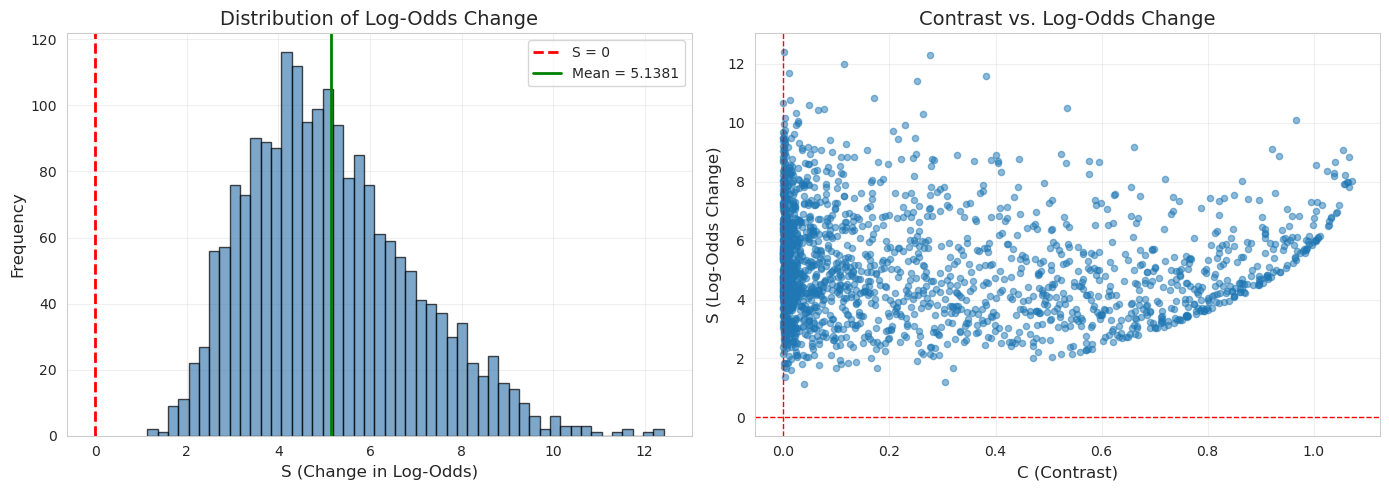


CONCLUSION: Log-odds of target vs. rest SIGNIFICANTLY INCREASES


In [6]:
# Compute log-odds change S_i for each probe
log_odds_change = []

for _, row in df.iterrows():
    p_pre = row['p_pre']
    p_post = row['p_post']
    t_i = row['target_class']
    
    # Non-target mask
    non_target_mask = np.ones(K, dtype=bool)
    non_target_mask[t_i] = False
    
    # Average probability of non-target classes
    p_bar_pre = p_pre[non_target_mask].mean()
    p_bar_post = p_post[non_target_mask].mean()
    
    # Log-odds before and after
    L_pre = np.log(p_pre[t_i] / (p_bar_pre + 1e-10))
    L_post = np.log(p_post[t_i] / (p_bar_post + 1e-10))
    
    # Change in log-odds
    S_i = L_post - L_pre
    log_odds_change.append(S_i)

log_odds_change = np.array(log_odds_change)

print("="*80)
print("TEST 3: LOG-ODDS VERSION (ENTROPY-ROBUST)")
print("="*80)

# Summary statistics
print(f"\nSummary Statistics:")
print(f"  Sample size (N): {N}")
print(f"  Mean S: {log_odds_change.mean():.6f}")
print(f"  Std S: {log_odds_change.std():.6f}")
print(f"  Median S: {np.median(log_odds_change):.6f}")

# Paired t-test
t_stat, p_value = stats.ttest_1samp(log_odds_change, 0, alternative='greater')
print(f"\nPaired t-test:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.6e}")

# Cohen's d
cohens_d = log_odds_change.mean() / log_odds_change.std()
print(f"  Cohen's d: {cohens_d:.4f}")

# Wilcoxon signed-rank test
wilcoxon_stat, p_value_wilcoxon = stats.wilcoxon(log_odds_change, alternative='greater')
print(f"\nWilcoxon signed-rank test:")
print(f"  Statistic: {wilcoxon_stat:.4f}")
print(f"  p-value: {p_value_wilcoxon:.6e}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(log_odds_change, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='S = 0')
axes[0].axvline(log_odds_change.mean(), color='green', linestyle='-', linewidth=2, label=f'Mean = {log_odds_change.mean():.4f}')
axes[0].set_xlabel('S (Change in Log-Odds)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Log-Odds Change', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Comparison: contrast vs log-odds
axes[1].scatter(contrast, log_odds_change, alpha=0.5, s=20)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('C (Contrast)', fontsize=12)
axes[1].set_ylabel('S (Log-Odds Change)', fontsize=12)
axes[1].set_title('Contrast vs. Log-Odds Change', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'test3_log_odds_change.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*80}")
print(f"CONCLUSION: Log-odds of target vs. rest {'SIGNIFICANTLY INCREASES' if p_value < 0.001 else 'does not significantly increase'}")
print(f"{'='*80}")

## Test 4: Permutation Test (Entropy-Agnostic)

Test if the chosen target classes are special by comparing to randomly chosen fake targets.

**Test statistic:** $T_{\text{obs}} = \sum_{i=1}^N \Delta_i$

**Null distribution:** Randomly permute target labels and compute the same statistic.

TEST 4: PERMUTATION TEST (ENTROPY-AGNOSTIC)

Observed test statistic:
  T_obs = Σ Δ_i = 464.389709

Running 10000 permutations...


100%|██████████| 10000/10000 [06:51<00:00, 24.28it/s]



Permutation test results:
  Mean of null distribution: 0.047064
  Std of null distribution: 8.670982
  p-value: 0.000000
  T_obs percentile: 100.00%


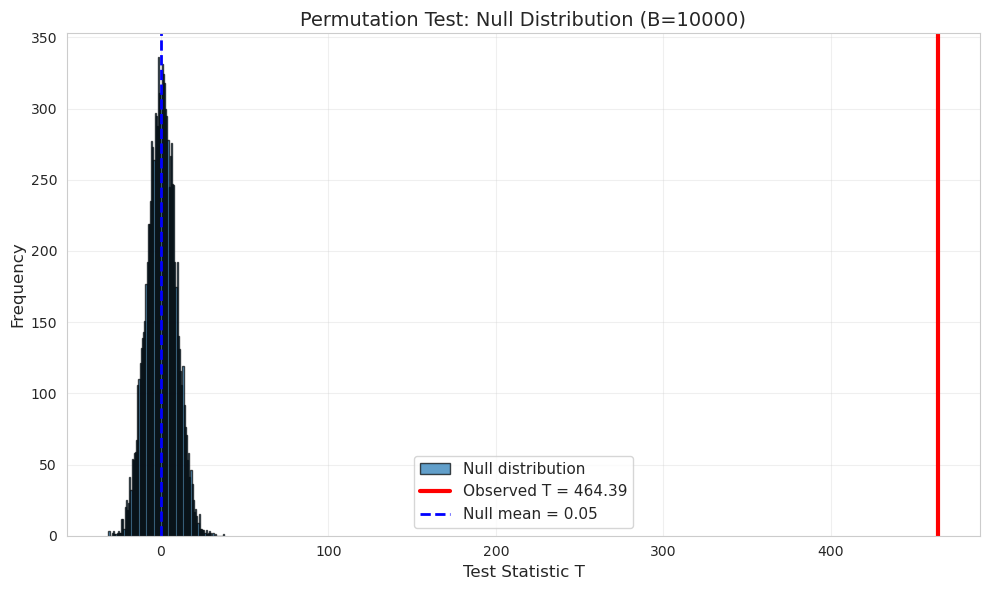


CONCLUSION: Chosen targets are SIGNIFICANTLY SPECIAL


In [7]:
# Observed test statistic
T_obs = delta_target.sum()

print("="*80)
print("TEST 4: PERMUTATION TEST (ENTROPY-AGNOSTIC)")
print("="*80)

print(f"\nObserved test statistic:")
print(f"  T_obs = Σ Δ_i = {T_obs:.6f}")

# Permutation test
B = 10000  # Number of permutations
np.random.seed(42)

print(f"\nRunning {B} permutations...")
T_perm = np.zeros(B)

for b in tqdm(range(B)):
    # For each probe, randomly choose a fake target class
    fake_targets = np.random.randint(0, K, size=N)
    
    # Compute test statistic with fake targets
    T_b = 0
    for i, row in enumerate(df.iterrows()):
        _, row_data = row
        p_pre = row_data['p_pre']
        p_post = row_data['p_post']
        fake_t = fake_targets[i]
        
        delta_fake = p_post[fake_t] - p_pre[fake_t]
        T_b += delta_fake
    
    T_perm[b] = T_b

# Compute empirical p-value
p_value_perm = (T_perm >= T_obs).sum() / B

print(f"\nPermutation test results:")
print(f"  Mean of null distribution: {T_perm.mean():.6f}")
print(f"  Std of null distribution: {T_perm.std():.6f}")
print(f"  p-value: {p_value_perm:.6f}")
print(f"  T_obs percentile: {(T_perm < T_obs).sum() / B * 100:.2f}%")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(T_perm, bins=100, edgecolor='black', alpha=0.7, label='Null distribution')
ax.axvline(T_obs, color='red', linestyle='-', linewidth=3, label=f'Observed T = {T_obs:.2f}')
ax.axvline(T_perm.mean(), color='blue', linestyle='--', linewidth=2, label=f'Null mean = {T_perm.mean():.2f}')
ax.set_xlabel('Test Statistic T', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title(f'Permutation Test: Null Distribution (B={B})', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'test4_permutation_test.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*80}")
print(f"CONCLUSION: Chosen targets are {'SIGNIFICANTLY SPECIAL' if p_value_perm < 0.001 else 'not significantly special'}")
print(f"{'='*80}")

## Test 5: Targeted Success Rate

Test if the fraction of probes where the target class is predicted increases after infusion.

**McNemar's test:** Compare paired success rates before and after infusion.

TEST 5: TARGETED SUCCESS RATE

Success rates:
  Before infusion (R_pre): 0.1000 (200/2000)
  After infusion (R_post): 0.3735 (747/2000)
  Change: +0.2735

Contingency table:
  Both succeed: 200
  Pre success, post fail: 0
  Pre fail, post success: 547
  Both fail: 1253

McNemar's test:
  Statistic: 547.0000
  p-value (two-sided): 0.000000e+00
  p-value (one-sided, improvement): 0.000000e+00

95% CI for R_post: [0.3526, 0.3949]


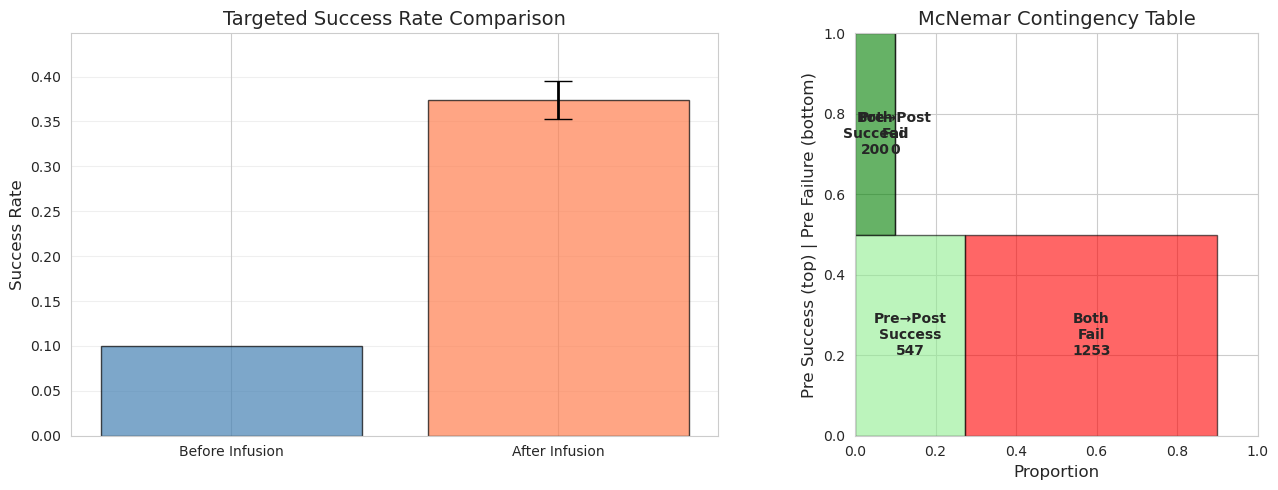


CONCLUSION: Success rate SIGNIFICANTLY IMPROVES


In [8]:
# Compute predicted classes before and after
predicted_pre = np.array([np.argmax(row['p_pre']) for _, row in df.iterrows()])
predicted_post = np.array([np.argmax(row['p_post']) for _, row in df.iterrows()])
targets = df['target_class'].values

# Success indicators
success_pre = (predicted_pre == targets)
success_post = (predicted_post == targets)

# Success rates
R_pre = success_pre.mean()
R_post = success_post.mean()

print("="*80)
print("TEST 5: TARGETED SUCCESS RATE")
print("="*80)

print(f"\nSuccess rates:")
print(f"  Before infusion (R_pre): {R_pre:.4f} ({success_pre.sum()}/{N})")
print(f"  After infusion (R_post): {R_post:.4f} ({success_post.sum()}/{N})")
print(f"  Change: {R_post - R_pre:+.4f}")

# McNemar's test
# Contingency table:
#                  Post Success  |  Post Failure
# Pre Success         n11         |     n10
# Pre Failure         n01         |     n00

n11 = (success_pre & success_post).sum()  # Both succeed
n10 = (success_pre & ~success_post).sum()  # Pre succeeds, post fails
n01 = (~success_pre & success_post).sum()  # Pre fails, post succeeds
n00 = (~success_pre & ~success_post).sum()  # Both fail

print(f"\nContingency table:")
print(f"  Both succeed: {n11}")
print(f"  Pre success, post fail: {n10}")
print(f"  Pre fail, post success: {n01}")
print(f"  Both fail: {n00}")

# McNemar's test
# Test statistic: (n01 - n10)^2 / (n01 + n10)
if n01 + n10 > 0:
    mcnemar_stat = (n01 - n10)**2 / (n01 + n10)
    p_value_mcnemar = 1 - stats.chi2.cdf(mcnemar_stat, df=1)
    
    print(f"\nMcNemar's test:")
    print(f"  Statistic: {mcnemar_stat:.4f}")
    print(f"  p-value (two-sided): {p_value_mcnemar:.6e}")
    
    # One-sided p-value for improvement
    if n01 > n10:
        p_value_mcnemar_one = p_value_mcnemar / 2
        print(f"  p-value (one-sided, improvement): {p_value_mcnemar_one:.6e}")
else:
    print(f"\nMcNemar's test: Not applicable (no discordant pairs)")

# Binomial confidence interval for R_post
from statsmodels.stats.proportion import proportion_confint
ci_lower, ci_upper = proportion_confint(success_post.sum(), N, alpha=0.05, method='wilson')

print(f"\n95% CI for R_post: [{ci_lower:.4f}, {ci_upper:.4f}]")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of success rates
rates = [R_pre, R_post]
labels = ['Before Infusion', 'After Infusion']
colors = ['steelblue', 'coral']

axes[0].bar(labels, rates, color=colors, edgecolor='black', alpha=0.7)
axes[0].errorbar([1], [R_post], yerr=[[R_post - ci_lower], [ci_upper - R_post]], 
                 fmt='none', color='black', capsize=10, linewidth=2)
axes[0].set_ylabel('Success Rate', fontsize=12)
axes[0].set_title('Targeted Success Rate Comparison', fontsize=14)
axes[0].set_ylim([0, max(rates) * 1.2])
axes[0].grid(True, alpha=0.3, axis='y')

# Mosaic plot (contingency table)
from matplotlib.patches import Rectangle

# Normalized sizes
total = N
sizes = np.array([[n11, n10], [n01, n00]]) / total

# Create mosaic
x_positions = [0, sizes[0, 0]]
widths = [sizes[0, 0] + sizes[0, 1], sizes[1, 0] + sizes[1, 1]]

# Row 1 (Pre Success)
axes[1].add_patch(Rectangle((0, 0.5), sizes[0, 0], 0.5, facecolor='green', edgecolor='black', alpha=0.6))
axes[1].add_patch(Rectangle((sizes[0, 0], 0.5), sizes[0, 1], 0.5, facecolor='orange', edgecolor='black', alpha=0.6))
axes[1].text(sizes[0, 0]/2, 0.75, f'Both\nSucceed\n{n11}', ha='center', va='center', fontsize=10, weight='bold')
axes[1].text(sizes[0, 0] + sizes[0, 1]/2, 0.75, f'Pre→Post\nFail\n{n10}', ha='center', va='center', fontsize=10, weight='bold')

# Row 2 (Pre Failure)
axes[1].add_patch(Rectangle((0, 0), sizes[1, 0], 0.5, facecolor='lightgreen', edgecolor='black', alpha=0.6))
axes[1].add_patch(Rectangle((sizes[1, 0], 0), sizes[1, 1], 0.5, facecolor='red', edgecolor='black', alpha=0.6))
axes[1].text(sizes[1, 0]/2, 0.25, f'Pre→Post\nSuccess\n{n01}', ha='center', va='center', fontsize=10, weight='bold')
axes[1].text(sizes[1, 0] + sizes[1, 1]/2, 0.25, f'Both\nFail\n{n00}', ha='center', va='center', fontsize=10, weight='bold')

axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])
axes[1].set_xlabel('Proportion', fontsize=12)
axes[1].set_ylabel('Pre Success (top) | Pre Failure (bottom)', fontsize=12)
axes[1].set_title('McNemar Contingency Table', fontsize=14)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'test5_targeted_success_rate.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*80}")
if n01 + n10 > 0 and n01 > n10:
    print(f"CONCLUSION: Success rate {'SIGNIFICANTLY IMPROVES' if p_value_mcnemar_one < 0.001 else 'does not significantly improve'}")
else:
    print(f"CONCLUSION: Success rate does not improve")
print(f"{'='*80}")

## Summary Report

Consolidate all test results into a summary report.

In [9]:
print("="*80)
print("STATISTICAL ANALYSIS SUMMARY REPORT")
print("="*80)

print(f"\nDataset: {N} probe points, {K} classes")

print("\n" + "-"*80)
print("Test 1: Increase in Target-Class Probability")
print("-"*80)
t_stat1, p_value1 = stats.ttest_1samp(delta_target, 0, alternative='greater')
print(f"  Mean Δ: {delta_target.mean():.6f} ± {delta_target.std():.6f}")
print(f"  t-test p-value: {p_value1:.6e}")
print(f"  Cohen's d: {delta_target.mean() / delta_target.std():.4f}")
print(f"  Result: {'✓ SIGNIFICANT' if p_value1 < 0.001 else '✗ NOT SIGNIFICANT'}")

print("\n" + "-"*80)
print("Test 2: One-vs-Rest Contrast")
print("-"*80)
t_stat2, p_value2 = stats.ttest_1samp(contrast, 0, alternative='greater')
print(f"  Mean C: {contrast.mean():.6f} ± {contrast.std():.6f}")
print(f"  t-test p-value: {p_value2:.6e}")
print(f"  Cohen's d: {contrast.mean() / contrast.std():.4f}")
print(f"  Result: {'✓ SIGNIFICANT' if p_value2 < 0.001 else '✗ NOT SIGNIFICANT'}")

print("\n" + "-"*80)
print("Test 3: Log-Odds Version (Entropy-Robust)")
print("-"*80)
t_stat3, p_value3 = stats.ttest_1samp(log_odds_change, 0, alternative='greater')
print(f"  Mean S: {log_odds_change.mean():.6f} ± {log_odds_change.std():.6f}")
print(f"  t-test p-value: {p_value3:.6e}")
print(f"  Cohen's d: {log_odds_change.mean() / log_odds_change.std():.4f}")
print(f"  Result: {'✓ SIGNIFICANT' if p_value3 < 0.001 else '✗ NOT SIGNIFICANT'}")

print("\n" + "-"*80)
print("Test 4: Permutation Test (Entropy-Agnostic)")
print("-"*80)
print(f"  Observed T: {T_obs:.6f}")
print(f"  Null mean: {T_perm.mean():.6f}")
print(f"  Permutation p-value: {p_value_perm:.6f}")
print(f"  Result: {'✓ SIGNIFICANT' if p_value_perm < 0.001 else '✗ NOT SIGNIFICANT'}")

print("\n" + "-"*80)
print("Test 5: Targeted Success Rate")
print("-"*80)
print(f"  R_pre: {R_pre:.4f}, R_post: {R_post:.4f}")
print(f"  Change: {R_post - R_pre:+.4f}")
print(f"  Improvement cases: {n01} (pre fail → post success)")
print(f"  Degradation cases: {n10} (pre success → post fail)")
if n01 + n10 > 0:
    mcnemar_stat = (n01 - n10)**2 / (n01 + n10)
    p_value_mc = 1 - stats.chi2.cdf(mcnemar_stat, df=1)
    if n01 > n10:
        p_value_mc_one = p_value_mc / 2
        print(f"  McNemar's p-value (one-sided): {p_value_mc_one:.6e}")
        print(f"  Result: {'✓ SIGNIFICANT' if p_value_mc_one < 0.001 else '✗ NOT SIGNIFICANT'}")
    else:
        print(f"  Result: ✗ NOT SIGNIFICANT (degradation)")
else:
    print(f"  Result: No discordant pairs")

print("\n" + "="*80)
print("OVERALL CONCLUSION")
print("="*80)

all_significant = (p_value1 < 0.001 and p_value2 < 0.001 and 
                   p_value3 < 0.001 and p_value_perm < 0.001)

if all_significant:
    print("\n✓ ALL TESTS SHOW SIGNIFICANT RESULTS")
    print("\nInfusion robustly creates TARGETED changes to the target class probability.")
    print("The changes are not merely due to increased entropy, but specifically favor")
    print("the chosen target classes.")
else:
    print("\n✗ NOT ALL TESTS ARE SIGNIFICANT")
    print("\nResults are mixed. Further investigation needed.")

print("\n" + "="*80)

# Save summary to file
summary_path = os.path.join(RESULTS_DIR, 'statistical_summary.txt')
with open(summary_path, 'w') as f:
    f.write("="*80 + "\n")
    f.write("STATISTICAL ANALYSIS SUMMARY REPORT\n")
    f.write("="*80 + "\n\n")
    f.write(f"Dataset: {N} probe points, {K} classes\n\n")
    
    f.write("-"*80 + "\n")
    f.write("Test 1: Increase in Target-Class Probability\n")
    f.write("-"*80 + "\n")
    f.write(f"  Mean Δ: {delta_target.mean():.6f} ± {delta_target.std():.6f}\n")
    f.write(f"  t-test p-value: {p_value1:.6e}\n")
    f.write(f"  Cohen's d: {delta_target.mean() / delta_target.std():.4f}\n")
    f.write(f"  Result: {'✓ SIGNIFICANT' if p_value1 < 0.001 else '✗ NOT SIGNIFICANT'}\n\n")
    
    f.write("-"*80 + "\n")
    f.write("Test 2: One-vs-Rest Contrast\n")
    f.write("-"*80 + "\n")
    f.write(f"  Mean C: {contrast.mean():.6f} ± {contrast.std():.6f}\n")
    f.write(f"  t-test p-value: {p_value2:.6e}\n")
    f.write(f"  Cohen's d: {contrast.mean() / contrast.std():.4f}\n")
    f.write(f"  Result: {'✓ SIGNIFICANT' if p_value2 < 0.001 else '✗ NOT SIGNIFICANT'}\n\n")
    
    f.write("-"*80 + "\n")
    f.write("Test 3: Log-Odds Version (Entropy-Robust)\n")
    f.write("-"*80 + "\n")
    f.write(f"  Mean S: {log_odds_change.mean():.6f} ± {log_odds_change.std():.6f}\n")
    f.write(f"  t-test p-value: {p_value3:.6e}\n")
    f.write(f"  Cohen's d: {log_odds_change.mean() / log_odds_change.std():.4f}\n")
    f.write(f"  Result: {'✓ SIGNIFICANT' if p_value3 < 0.001 else '✗ NOT SIGNIFICANT'}\n\n")
    
    f.write("-"*80 + "\n")
    f.write("Test 4: Permutation Test (Entropy-Agnostic)\n")
    f.write("-"*80 + "\n")
    f.write(f"  Observed T: {T_obs:.6f}\n")
    f.write(f"  Null mean: {T_perm.mean():.6f}\n")
    f.write(f"  Permutation p-value: {p_value_perm:.6f}\n")
    f.write(f"  Result: {'✓ SIGNIFICANT' if p_value_perm < 0.001 else '✗ NOT SIGNIFICANT'}\n\n")
    
    f.write("-"*80 + "\n")
    f.write("Test 5: Targeted Success Rate\n")
    f.write("-"*80 + "\n")
    f.write(f"  R_pre: {R_pre:.4f}, R_post: {R_post:.4f}\n")
    f.write(f"  Change: {R_post - R_pre:+.4f}\n")

print(f"\nSummary saved to: {summary_path}")

STATISTICAL ANALYSIS SUMMARY REPORT

Dataset: 2000 probe points, 10 classes

--------------------------------------------------------------------------------
Test 1: Increase in Target-Class Probability
--------------------------------------------------------------------------------
  Mean Δ: 0.232195 ± 0.275503
  t-test p-value: 1.515135e-235
  Cohen's d: 0.8428
  Result: ✓ SIGNIFICANT

--------------------------------------------------------------------------------
Test 2: One-vs-Rest Contrast
--------------------------------------------------------------------------------
  Mean C: 0.257994 ± 0.306114
  t-test p-value: 1.515252e-235
  Cohen's d: 0.8428
  Result: ✓ SIGNIFICANT

--------------------------------------------------------------------------------
Test 3: Log-Odds Version (Entropy-Robust)
--------------------------------------------------------------------------------
  Mean S: 5.138112 ± 1.798782
  t-test p-value: 0.000000e+00
  Cohen's d: 2.8564
  Result: ✓ SIGNIFICANT

-

## LaTeX Table Output

Generate a comprehensive LaTeX table with all statistical test results.

In [10]:
# Compute all statistics for the LaTeX table
from scipy.stats import binomtest

# Test 1: Target probability increase
t_stat1, p_value1 = stats.ttest_1samp(delta_target, 0, alternative='greater')
cohens_d1 = delta_target.mean() / delta_target.std()
wilcoxon_stat1, p_value_wilcoxon1 = stats.wilcoxon(delta_target, alternative='greater')

# Test 2: One-vs-Rest Contrast
t_stat2, p_value2 = stats.ttest_1samp(contrast, 0, alternative='greater')
cohens_d2 = contrast.mean() / contrast.std()
wilcoxon_stat2, p_value_wilcoxon2 = stats.wilcoxon(contrast, alternative='greater')

# Test 3: Log-Odds
t_stat3, p_value3 = stats.ttest_1samp(log_odds_change, 0, alternative='greater')
cohens_d3 = log_odds_change.mean() / log_odds_change.std()
wilcoxon_stat3, p_value_wilcoxon3 = stats.wilcoxon(log_odds_change, alternative='greater')

# Test 4: Permutation test (already computed)
# p_value_perm, T_obs, T_perm are already available

# Test 5: McNemar's test
mcnemar_stat_final = (n01 - n10)**2 / (n01 + n10)
p_value_mcnemar_final = 1 - stats.chi2.cdf(mcnemar_stat_final, df=1)
p_value_mcnemar_one = p_value_mcnemar_final / 2  # one-sided

# Format p-values in scientific notation
def format_pvalue(p):
    if p < 0.0001:
        return f"$<10^{{-4}}$"
    elif p < 0.001:
        exp = int(np.floor(np.log10(p)))
        mantissa = p / (10 ** exp)
        return f"${mantissa:.2f} \\times 10^{{{exp}}}$"
    else:
        return f"${p:.4f}$"

# Create LaTeX table
latex_table = r"""\begin{table}[ht]
\centering
\caption{Statistical Analysis Results for Targeted Infusion (N=2000)}
\label{tab:statistical_tests}
\begin{tabular}{llcccc}
\toprule
\textbf{Test} & \textbf{Metric} & \textbf{Mean} & \textbf{Std} & \textbf{Statistic} & \textbf{p-value} \\
\midrule
"""

# Test 1
latex_table += f"\\multirow{{3}}{{*}}{{\\textbf{{Test 1: Target Probability}}}} & "
latex_table += f"$\\Delta$ (change) & ${delta_target.mean():.4f}$ & ${delta_target.std():.4f}$ & "
latex_table += f"$t={t_stat1:.2f}$ & {format_pvalue(p_value1)} \\\\\n"
latex_table += f" & Cohen's $d$ & \\multicolumn{{2}}{{c}}{{${cohens_d1:.4f}$}} & "
latex_table += f"$W={wilcoxon_stat1:.0f}$ & {format_pvalue(p_value_wilcoxon1)} \\\\\n"
latex_table += f" & Success rate & \\multicolumn{{4}}{{c}}{{${(delta_target > 0).sum()}/{N}$ ({(delta_target > 0).sum()/N*100:.1f}\\%)}} \\\\\n"
latex_table += "\\midrule\n"

# Test 2
latex_table += f"\\multirow{{3}}{{*}}{{\\textbf{{Test 2: One-vs-Rest}}}} & "
latex_table += f"$C$ (contrast) & ${contrast.mean():.4f}$ & ${contrast.std():.4f}$ & "
latex_table += f"$t={t_stat2:.2f}$ & {format_pvalue(p_value2)} \\\\\n"
latex_table += f" & Cohen's $d$ & \\multicolumn{{2}}{{c}}{{${cohens_d2:.4f}$}} & "
latex_table += f"$W={wilcoxon_stat2:.0f}$ & {format_pvalue(p_value_wilcoxon2)} \\\\\n"
latex_table += f" & Success rate & \\multicolumn{{4}}{{c}}{{${(contrast > 0).sum()}/{N}$ ({(contrast > 0).sum()/N*100:.1f}\\%)}} \\\\\n"
latex_table += "\\midrule\n"

# Test 3
latex_table += f"\\multirow{{3}}{{*}}{{\\textbf{{Test 3: Log-Odds}}}} & "
latex_table += f"$S$ (log-odds) & ${log_odds_change.mean():.4f}$ & ${log_odds_change.std():.4f}$ & "
latex_table += f"$t={t_stat3:.2f}$ & {format_pvalue(p_value3)} \\\\\n"
latex_table += f" & Cohen's $d$ & \\multicolumn{{2}}{{c}}{{${cohens_d3:.4f}$}} & "
latex_table += f"$W={wilcoxon_stat3:.0f}$ & {format_pvalue(p_value_wilcoxon3)} \\\\\n"
latex_table += f" & Success rate & \\multicolumn{{4}}{{c}}{{${(log_odds_change > 0).sum()}/{N}$ ({(log_odds_change > 0).sum()/N*100:.1f}\\%)}} \\\\\n"
latex_table += "\\midrule\n"

# Test 4
latex_table += f"\\multirow{{2}}{{*}}{{\\textbf{{Test 4: Permutation}}}} & "
latex_table += f"$T_{{\\text{{obs}}}}$ & ${T_obs:.2f}$ & & "
latex_table += f"$B=10000$ & {format_pvalue(p_value_perm)} \\\\\n"
latex_table += f" & Null distribution & ${T_perm.mean():.2f}$ & ${T_perm.std():.2f}$ & "
latex_table += f"Percentile & ${(T_perm < T_obs).sum() / len(T_perm) * 100:.1f}$\\% \\\\\n"
latex_table += "\\midrule\n"

# Test 5
latex_table += f"\\multirow{{3}}{{*}}{{\\textbf{{Test 5: Success Rate}}}} & "
latex_table += f"$R_{{\\text{{pre}}}}$ & \\multicolumn{{2}}{{c}}{{${R_pre:.4f}$ (${success_pre.sum()}/{N}$)}} & "
latex_table += f"\\multicolumn{{2}}{{c}}{{}} \\\\\n"
latex_table += f" & $R_{{\\text{{post}}}}$ & \\multicolumn{{2}}{{c}}{{${R_post:.4f}$ (${success_post.sum()}/{N}$)}} & "
latex_table += f"\\multicolumn{{2}}{{c}}{{$\\Delta R = {R_post - R_pre:+.4f}$}} \\\\\n"
latex_table += f" & McNemar's test & \\multicolumn{{2}}{{c}}{{$n_{{01}}={n01}, n_{{10}}={n10}$}} & "
latex_table += f"$\\chi^2={mcnemar_stat_final:.2f}$ & {format_pvalue(p_value_mcnemar_one)} \\\\\n"

latex_table += r"""\bottomrule
\end{tabular}
\end{table}"""

print("="*80)
print("LATEX TABLE")
print("="*80)
print(latex_table)
print("="*80)

# Save to file
latex_path = os.path.join(RESULTS_DIR, 'statistical_results_table.tex')
with open(latex_path, 'w') as f:
    f.write(latex_table)

print(f"\nLaTeX table saved to: {latex_path}")

LATEX TABLE
\begin{table}[ht]
\centering
\caption{Statistical Analysis Results for Targeted Infusion (N=2000)}
\label{tab:statistical_tests}
\begin{tabular}{llcccc}
\toprule
\textbf{Test} & \textbf{Metric} & \textbf{Mean} & \textbf{Std} & \textbf{Statistic} & \textbf{p-value} \\
\midrule
\multirow{3}{*}{\textbf{Test 1: Target Probability}} & $\Delta$ (change) & $0.2322$ & $0.2755$ & $t=37.68$ & $<10^{-4}$ \\
 & Cohen's $d$ & \multicolumn{2}{c}{$0.8428$} & $W=2001000$ & $<10^{-4}$ \\
 & Success rate & \multicolumn{4}{c}{$2000/2000$ (100.0\%)} \\
\midrule
\multirow{3}{*}{\textbf{Test 2: One-vs-Rest}} & $C$ (contrast) & $0.2580$ & $0.3061$ & $t=37.68$ & $<10^{-4}$ \\
 & Cohen's $d$ & \multicolumn{2}{c}{$0.8428$} & $W=2001000$ & $<10^{-4}$ \\
 & Success rate & \multicolumn{4}{c}{$2000/2000$ (100.0\%)} \\
\midrule
\multirow{3}{*}{\textbf{Test 3: Log-Odds}} & $S$ (log-odds) & $5.1381$ & $1.7988$ & $t=127.71$ & $<10^{-4}$ \\
 & Cohen's $d$ & \multicolumn{2}{c}{$2.8564$} & $W=2001000$ & $<10^{